# 09 — Long-Run PD and Rating Transition Matrices

## Building the probability of default

This notebook assigns the first IRB component. Transparent synthetic one-year transition matrices provide a default-column probability for each borrower grade or retail pool.

PD affects expected loss, correlation, conditional default probability and capital K. A higher assigned PD generally increases IRB RWA, although the formula is nonlinear.

### How to read the transition tables

| Term | Simple meaning |
|---|---|
| Long-run PD | average one-year default experience across representative good and bad years |
| Transition matrix | probabilities of staying in a grade, migrating or defaulting over one year |
| D column | the probability of moving to default within one year |
| Count weighted | based on numbers of borrowers rather than exposure amounts |

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))
from basel_credit_risk.config import load_all_config
from basel_credit_risk.notebook_support import display, ensure_outputs

CRORE = 10_000_000
COLORS = ["#0B3A53", "#1F77B4", "#2A9D8F", "#E9C46A", "#F4A261", "#E76F51"]
sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_colwidth", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", None)
configs = load_all_config(ROOT / "config")
ensure_outputs(ROOT)
loans = pd.read_csv(ROOT / "data/processed/current_calculated.csv.gz", low_memory=False)
print(f"Portfolio represented: {len(loans):,} synthetic exposures")

Portfolio represented: 30,000 synthetic exposures


> The transition probabilities are synthetic. A bank would estimate long-run one-year PD from multi-year borrower counts and defaults by grade or retail pool, covering representative good and bad years and adding conservatism for uncertainty.

## Synthetic matrices by IRB exposure family

Basel does not prescribe these numerical transition probabilities. The project uses deliberately labelled synthetic anchors that follow believable ordering: stronger grades default less often and weaker grades migrate or default more often. Real IRB estimation requires observed multi-year data and validation.

In [2]:
from basel_credit_risk.pd_transition import build_transition_matrix

transition_config = configs["pd_transition_assumptions"]
matrices = {}
for profile_name, profile in transition_config["profiles"].items():
    matrix = build_transition_matrix(
        profile,
        transition_config["matrix_method"],
        transition_config["grade_order"],
    )
    matrices[profile_name] = matrix
    print(profile_name.replace("_", " ").upper())
    display(matrix.style.format("{:.3%}"))

SOVEREIGN


,AAA,AA,A,BBB,BB,B,CCC,D
From grade,,,,,,,,
AAA,89.000%,10.999%,0.000%,0.000%,0.000%,0.000%,0.000%,0.001%
AA,5.000%,84.000%,10.995%,0.000%,0.000%,0.000%,0.000%,0.005%
A,0.000%,5.000%,84.000%,10.980%,0.000%,0.000%,0.000%,0.020%
BBB,0.000%,0.000%,5.000%,84.000%,10.920%,0.000%,0.000%,0.080%
BB,0.000%,0.000%,0.000%,5.000%,84.000%,10.400%,0.000%,0.600%
B,0.000%,0.000%,0.000%,0.000%,5.000%,84.000%,8.000%,3.000%
CCC,0.000%,0.000%,0.000%,0.000%,0.000%,2.000%,84.000%,14.000%
D,0.000%,0.000%,0.000%,0.000%,0.000%,0.000%,0.000%,100.000%


BANK


,AAA,AA,A,BBB,BB,B,CCC,D
From grade,,,,,,,,
AAA,89.000%,10.997%,0.000%,0.000%,0.000%,0.000%,0.000%,0.003%
AA,5.000%,84.000%,10.990%,0.000%,0.000%,0.000%,0.000%,0.010%
A,0.000%,5.000%,84.000%,10.960%,0.000%,0.000%,0.000%,0.040%
BBB,0.000%,0.000%,5.000%,84.000%,10.850%,0.000%,0.000%,0.150%
BB,0.000%,0.000%,0.000%,5.000%,84.000%,10.000%,0.000%,1.000%
B,0.000%,0.000%,0.000%,0.000%,5.000%,84.000%,6.500%,4.500%
CCC,0.000%,0.000%,0.000%,0.000%,0.000%,0.000%,82.000%,18.000%
D,0.000%,0.000%,0.000%,0.000%,0.000%,0.000%,0.000%,100.000%


CORPORATE


...

,AAA,AA,A,BBB,BB,B,CCC,D
From grade,,,,,,,,
AAA,89.000%,10.990%,0.000%,0.000%,0.000%,0.000%,0.000%,0.010%
AA,5.000%,84.000%,10.970%,0.000%,0.000%,0.000%,0.000%,0.030%
A,0.000%,5.000%,84.000%,10.900%,0.000%,0.000%,0.000%,0.100%
BBB,0.000%,0.000%,5.000%,84.000%,10.600%,0.000%,0.000%,0.400%
BB,0.000%,0.000%,0.000%,5.000%,84.000%,9.200%,0.000%,1.800%
B,0.000%,0.000%,0.000%,0.000%,5.000%,84.000%,4.500%,6.500%
CCC,0.000%,0.000%,0.000%,0.000%,0.000%,0.000%,80.000%,20.000%
D,0.000%,0.000%,0.000%,0.000%,0.000%,0.000%,0.000%,100.000%


QUALIFYING REVOLVING RETAIL


,AAA,AA,A,BBB,BB,B,CCC,D
From grade,,,,,,,,
AAA,89.000%,10.980%,0.000%,0.000%,0.000%,0.000%,0.000%,0.020%
AA,5.000%,84.000%,10.940%,0.000%,0.000%,0.000%,0.000%,0.060%
A,0.000%,5.000%,84.000%,10.800%,0.000%,0.000%,0.000%,0.200%
BBB,0.000%,0.000%,5.000%,84.000%,10.300%,0.000%,0.000%,0.700%
BB,0.000%,0.000%,0.000%,5.000%,84.000%,8.200%,0.000%,2.800%
B,0.000%,0.000%,0.000%,0.000%,5.000%,84.000%,2.000%,9.000%
CCC,0.000%,0.000%,0.000%,0.000%,0.000%,0.000%,74.000%,26.000%
D,0.000%,0.000%,0.000%,0.000%,0.000%,0.000%,0.000%,100.000%


OTHER RETAIL


,AAA,AA,A,BBB,BB,B,CCC,D
From grade,,,,,,,,
AAA,89.000%,10.985%,0.000%,0.000%,0.000%,0.000%,0.000%,0.015%
AA,5.000%,84.000%,10.950%,0.000%,0.000%,0.000%,0.000%,0.050%
A,0.000%,5.000%,84.000%,10.840%,0.000%,0.000%,0.000%,0.160%
BBB,0.000%,0.000%,5.000%,84.000%,10.400%,0.000%,0.000%,0.600%
BB,0.000%,0.000%,0.000%,5.000%,84.000%,8.600%,0.000%,2.400%
B,0.000%,0.000%,0.000%,0.000%,5.000%,84.000%,3.000%,8.000%
CCC,0.000%,0.000%,0.000%,0.000%,0.000%,0.000%,76.000%,24.000%
D,0.000%,0.000%,0.000%,0.000%,0.000%,0.000%,0.000%,100.000%


Each row totals 100%. The D column is carried into the loan dataset as the long-run one-year PD for that grade or retail pool. The matrices are not presented as agency data or a fitted model.

## Long-run PD curves across exposure families

The chart compares the D-column probabilities. It makes the assumptions visible: the same letter grade can have different default experience across sovereign, bank, corporate and retail families.

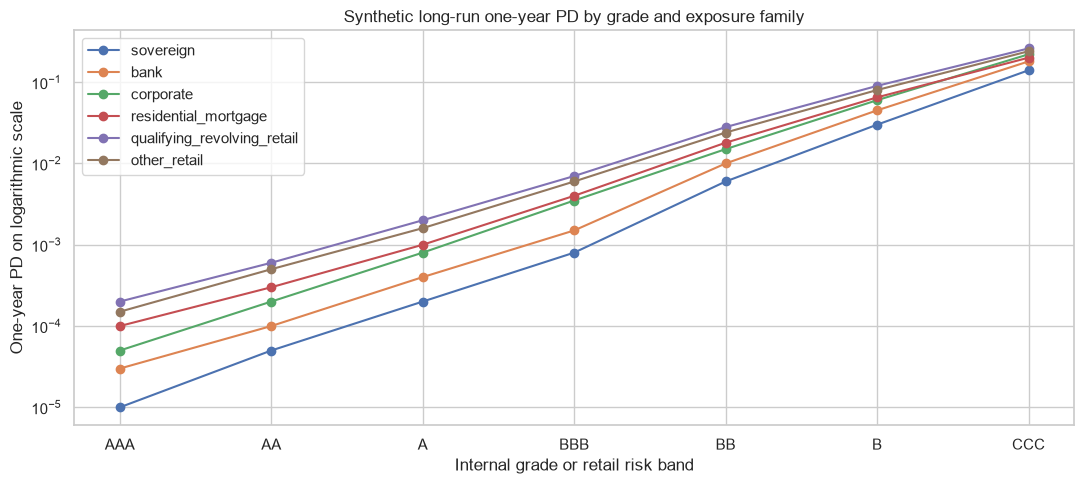

In [3]:
pd_curves = pd.DataFrame({
    profile: matrix.loc[matrix.index != "D", "D"]
    for profile, matrix in matrices.items()
})
pd_curves.plot(figsize=(11, 5), marker="o", title="Synthetic long-run one-year PD by grade and exposure family")
plt.yscale("log")
plt.xlabel("Internal grade or retail risk band")
plt.ylabel("One-year PD on logarithmic scale")
plt.tight_layout()
plt.show()

The logarithmic axis keeps very small investment-grade PDs visible beside weaker grades. The ordered increase is more important than a false claim of precise historical calibration.

## Assignment to individual loans

One loan from each profile and grade is shown with the transition profile, internal grade, D-column PD and regulatory PD after any floor or default treatment.

In [4]:
pd_examples = (
    loans.sort_values(["pd_transition_profile", "internal_grade", "exposure_id"])
    .groupby(["pd_transition_profile", "internal_grade"], as_index=False)
    .first()[["exposure_id", "pd_transition_profile", "internal_grade", "pd_long_run", "pd_floor_applied", "pd_regulatory", "pd_source"]]
)
display(pd_examples.style.format({"pd_long_run": "{:.3%}", "pd_floor_applied": "{:.3%}", "pd_regulatory": "{:.3%}"}))

,exposure_id,pd_transition_profile,internal_grade,pd_long_run,pd_floor_applied,pd_regulatory,pd_source
0,EXP-0027619,bank,A,0.040%,0.050%,0.050%,SYNTHETIC_LONG_RUN_TRANSITION_DEFAULT_COLUMN
1,EXP-0027607,bank,AA,0.010%,0.050%,0.050%,SYNTHETIC_LONG_RUN_TRANSITION_DEFAULT_COLUMN
2,EXP-0027604,bank,AAA,0.003%,0.050%,0.050%,SYNTHETIC_LONG_RUN_TRANSITION_DEFAULT_COLUMN
3,EXP-0027610,bank,B,100.000%,0.050%,100.000%,SYNTHETIC_LONG_RUN_TRANSITION_DEFAULT_COLUMN
4,EXP-0027613,bank,BB,1.000%,0.050%,1.000%,SYNTHETIC_LONG_RUN_TRANSITION_DEFAULT_COLUMN
5,EXP-0027640,bank,BBB,0.150%,0.050%,0.150%,SYNTHETIC_LONG_RUN_TRANSITION_DEFAULT_COLUMN
6,EXP-0027601,bank,CCC,18.000%,0.050%,18.000%,SYNTHETIC_LONG_RUN_TRANSITION_DEFAULT_COLUMN
7,EXP-0009610,corporate,A,0.080%,0.050%,0.080%,SYNTHETIC_LONG_RUN_TRANSITION_DEFAULT_COLUMN
8,EXP-0009607,corporate,AA,0.020%,0.050%,0.050%,SYNTHETIC_LONG_RUN_TRANSITION_DEFAULT_COLUMN
9,EXP-0009601,corporate,AAA,0.005%,0.050%,0.050%,SYNTHETIC_LONG_RUN_TRANSITION_DEFAULT_COLUMN


Loans do not receive random independent PDs after this step. They inherit the long-run PD of their grade or retail pool, preserving a coherent connection between the transition table and the capital calculation.

## The PD floor

The synthetic grade PD is separate from the regulatory floor. QRRE revolvers use a 0.10% floor; transactors and other non-sovereign exposures use 0.05%. Sovereigns have no PD floor in this selected treatment. Stress changes a separate scenario PD, leaving the long-run anchor unchanged.

In [5]:
display(loans.groupby(["irb_function", "retail_transactor"])["pd_floor_applied"].agg(["min", "max"]).style.format("{:.2%}"))